# CS166 – Social Media Bot Detection
## Data Loading & Preprocessing Notebook
**Team 1:** Aaminah Mohammed, Alex Chang, Jumana Ayoub  
**Course:** CS166 Information Security, Spring 2026  
**Instructor:** Professor Chao-Li Tarng

##Section 1: Data loading

In [1]:
#Section 1 loading the data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# load data from github
url = "https://raw.githubusercontent.com/aaminahmq/Datafiles/refs/heads/main/CS%20166%20group%20project/bot_detection_data.csv"
df = pd.read_csv(url)

print(f"Dataset loaded successfully!")
print(f"Total rows:    {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Dataset loaded successfully!
Total rows:    50000
Total columns: 11


##Section 2 Basic Data Exploration


In [2]:
# Column names and data types
print("Column names and data types:")
print(df.dtypes)

Column names and data types:
User ID           int64
Username            str
Tweet               str
Retweet Count     int64
Mention Count     int64
Follower Count    int64
Verified           bool
Bot Label         int64
Location            str
Created At          str
Hashtags            str
dtype: object


In [3]:
df.head()

,User ID,Username,Tweet,Retweet Count,Mention Count,Follower Count,Verified,Bot Label,Location,Created At,Hashtags
0,132131,flong,Station activity person against natural majori...,85,1,2353,False,1,Adkinston,2020-05-11 15:29:50,NaN
1,289683,hinesstephanie,Authority research natural life material staff...,55,5,9617,True,0,Sanderston,2022-11-26 05:18:10,both live
2,779715,roberttran,Manage whose quickly especially foot none to g...,6,2,4363,True,0,Harrisonfurt,2022-08-08 03:16:54,phone ahead
3,696168,pmason,Just cover eight opportunity strong policy which.,54,5,2242,True,1,Martinezberg,2021-08-14 22:27:05,ever quickly new I
4,704441,noah87,Animal sign six data good or.,26,3,8438,False,1,Camachoville,2020-04-13 21:24:21,foreign mention


In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
User ID              0
Username             0
Tweet                0
Retweet Count        0
Mention Count        0
Follower Count       0
Verified             0
Bot Label            0
Location             0
Created At           0
Hashtags          8341
dtype: int64


In [5]:
# How many bots vs real users?
print("Bot Label counts:")
print(df["Bot Label"].value_counts())
print()
print("(1 = Bot, 0 = Real User)")

Bot Label counts:
Bot Label
1    25018
0    24982
Name: count, dtype: int64

(1 = Bot, 0 = Real User)


## Section 3 Handle Missing Values
The Hashtags column has about 8341 missing values  
This just means those tweets had no hashtags, so we fill the blanks with an empty string instead of leaving them as NaN.


In [6]:
df["Hashtags"] = df["Hashtags"].fillna("")

print("Missing values after fix:")
print(df.isnull().sum())

Missing values after fix:
User ID           0
Username          0
Tweet             0
Retweet Count     0
Mention Count     0
Follower Count    0
Verified          0
Bot Label         0
Location          0
Created At        0
Hashtags          0
dtype: int64


##Section 4 Feature Engineering


In [7]:
# Account Age in days
df["Created At"] = pd.to_datetime(df["Created At"])
reference_date = pd.Timestamp("2024-01-01")
df["Account Age (Days)"] = (reference_date - df["Created At"]).dt.days

# Tweet length
df["Tweet Length"] = df["Tweet"].str.len()

# Hashtag count
df["Hashtag Count"] = df["Hashtags"].apply(
    lambda x: len(str(x).split()) if str(x).strip() != "" else 0
)

# Convert Verified True/False -> 1/0
df["Verified"] = df["Verified"].astype(int)

print("New features created successfully!")
df[["Account Age (Days)", "Tweet Length", "Hashtag Count", "Verified"]].head()

New features created successfully!


,Account Age (Days),Tweet Length,Hashtag Count,Verified
0,1329,83,0,0
1,400,77,2,1
2,510,61,2,1
3,869,49,4,1
4,1357,29,2,0


##Section 5 Features for the model

In [8]:
features = [
    "Retweet Count",
    "Mention Count",
    "Follower Count",
    "Verified",
    "Account Age (Days)",
    "Tweet Length",
    "Hashtag Count"
]

target = "Bot Label"

X = df[features]
y = df[target]

print("Features selected for the model:")
for f in features:
    print(f"  - {f}")
print(f"\nTarget: {target}  (1 = Bot, 0 = Real User)")

Features selected for the model:
  - Retweet Count
  - Mention Count
  - Follower Count
  - Verified
  - Account Age (Days)
  - Tweet Length
  - Hashtag Count

Target: Bot Label  (1 = Bot, 0 = Real User)


In [9]:
# Summary statistics for our selected features
X.describe().round(2)

,Retweet Count,Mention Count,Follower Count,Verified,Account Age (Days),Tweet Length,Hashtag Count
count,50000.00,50000.00,50000.00,50000.0,50000.00,50000.00,50000.00
mean,50.01,2.51,4988.60,0.5,838.24,62.63,2.50
std,29.18,1.71,2878.74,0.5,360.84,16.47,1.71
min,0.00,0.00,0.00,0.0,214.00,23.00,0.00
25%,25.00,1.00,2487.75,0.0,526.00,49.00,1.00
50%,50.00,3.00,4991.50,1.0,836.00,62.00,2.00
75%,75.00,4.00,7471.00,1.0,1153.00,76.00,4.00
max,100.00,5.00,10000.00,1.0,1460.00,118.00,5.00


## Section 6: Train / Test Split
We split the data so that:
- 80% is used to train the model
- 20% is used to test how well the model does on data it has never seen before

random_state=42 makes sure we get the same split every time we run the notebook

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")

Training set:  40000 rows
Test set:      10000 rows


##Section 7 feature scaling

In [11]:
 #scaling the features

scaler = StandardScaler()

# Fit on training data, then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete!")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print()
print("Data is ready for model training!")

Scaling complete!
X_train_scaled shape: (40000, 7)
X_test_scaled shape:  (10000, 7)

Data is ready for model training!


##Section 8 Data visualizations

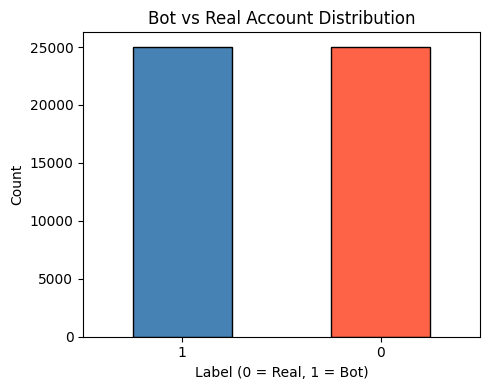

In [12]:
#bot vs real account distributions
plt.figure(figsize=(5, 4))
df["Bot Label"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"],
    edgecolor="black"
)
plt.title("Bot vs Real Account Distribution")
plt.xlabel("Label (0 = Real, 1 = Bot)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

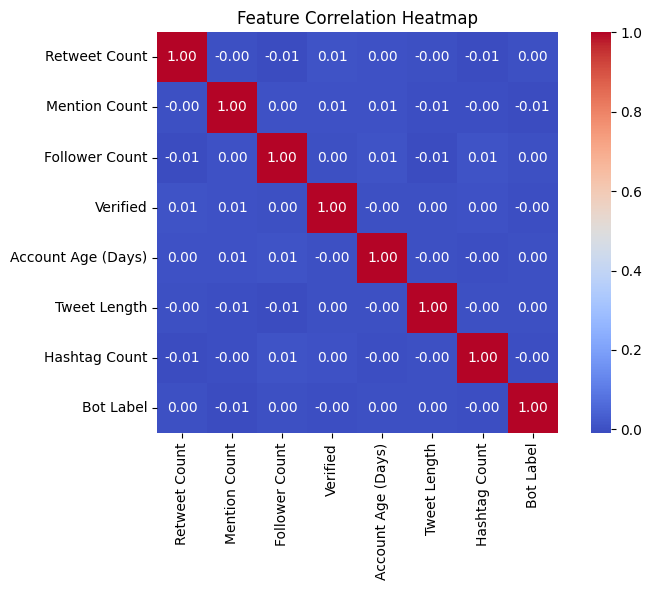

In [13]:
# feature correlation

plt.figure(figsize=(8, 6))
corr = df[features + [target]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## Section 7: The Models

### Random Forest Classifier

--- Model Performance ---
Accuracy Score: 0.5054

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.50      0.51      0.51      4968
           1       0.51      0.50      0.50      5032

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



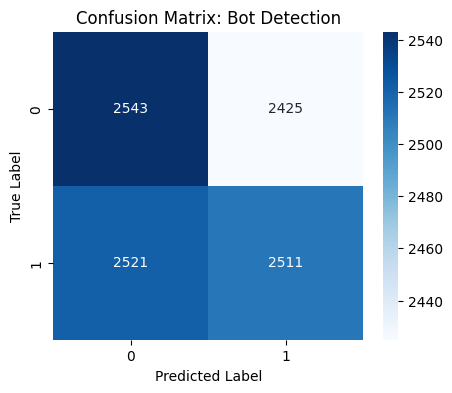

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the model
model = RandomForestClassifier(n_estimators=500, random_state=42)

# 2. Train the model
model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# 4. Evaluate the results
print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Visualize confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Bot Detection")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

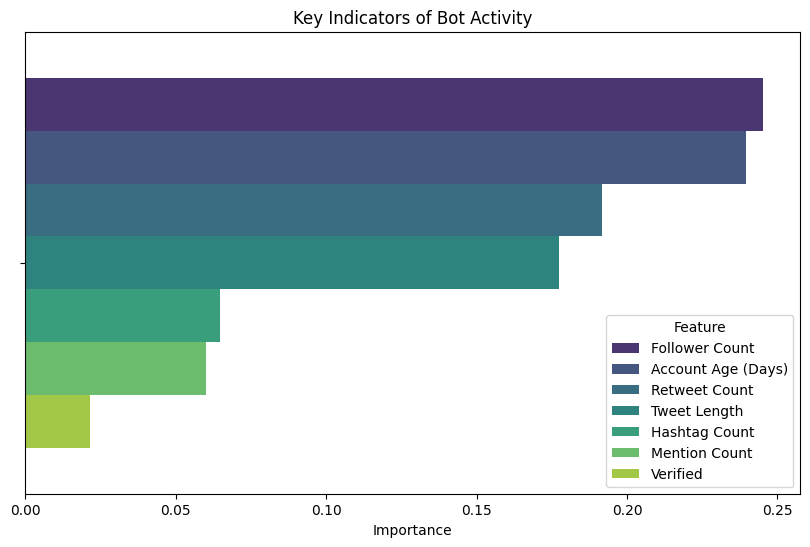

In [30]:
# Extract feature importance
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', hue='Feature', data=feature_importance_df, palette='viridis')
plt.title('Key Indicators of Bot Activity')
plt.show()

### Linear Regression

--- Model Performance ---
Accuracy Score: 0.5104

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.51      0.57      0.54      4968
           1       0.52      0.45      0.48      5032

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



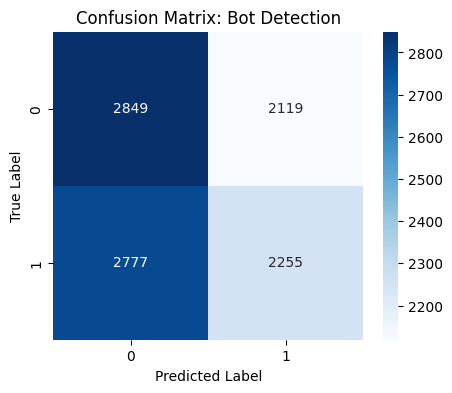

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the model
model = LogisticRegression(random_state=42)

# 2. Train the model
model.fit(X_train_scaled, y_train)

# 3. Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# 4. Evaluate the results
print("--- Model Performance ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 5. Visualize confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Bot Detection")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()